## Assignment 4 — LSTM-Based Time-Series Forecasting Develop an LSTM-based model for time-series forecasting using stock price, weather, or sales datasets.

## Import libraries

In [ ]:
!pip install tensorflow pandas numpy matplotlib scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [3]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## Load the dataset

We'll use Apple (AAPL) historical stock-price data.
A suitable ready-made dataset is available on GitHub containing AAPL daily stock prices from January 2020 to March 2024. It includes daily stock prices and trading volume.

Dataset download
You can download the CSV from: AAPL Historical Stock Dataset — GitHub

The dataset contains columns such as:
Date , Open , High ,Low ,Close ,Volume

The AAPL historical stock-price dataset contains daily stock information such as opening price, highest price, lowest price, closing price, and volume. For this project, the closing price is selected as the target variable
because the objective is to forecast future stock closing prices.

In [4]:
df = pd.read_csv("aapl_ticker.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (1054, 6)


,Open,High,Low,Close,Adj Close,Volume
0,74.059998,75.150002,73.797501,75.087502,73.059425,135480400
1,74.287498,75.144997,74.125000,74.357498,72.349144,146322800
2,73.447502,74.989998,73.187500,74.949997,72.925636,118387200
3,74.959999,75.224998,74.370003,74.597504,72.582649,108872000
4,74.290001,76.110001,74.290001,75.797501,73.750244,132079200


## Check the columns

In [13]:
# Display column names

print("Column names:")
print(df.columns.tolist())

Column names:
['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


## Understand the dataset

In [14]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1054 entries, 1970-01-01 00:00:00 to 1970-01-01 00:00:00.000001053
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1054 non-null   float64
 1   High       1054 non-null   float64
 2   Low        1054 non-null   float64
 3   Close      1054 non-null   float64
 4   Adj Close  1054 non-null   float64
 5   Volume     1054 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 57.6 KB


In [15]:
print("\nDataset Description:")
df.describe()


Dataset Description:


,Open,High,Low,Close,Adj Close,Volume
count,1054.000000,1054.000000,1054.000000,1054.000000,1054.000000,1.054000e+03
mean,142.657562,144.292863,141.125292,142.786698,141.258584,9.717401e+07
std,33.811668,33.910469,33.687311,33.810631,34.219064,5.390190e+07
min,57.020000,57.125000,53.152500,56.092499,54.706989,2.404830e+07
25%,124.684376,126.160004,123.099997,124.879999,122.800333,6.214598e+07
50%,147.019997,148.735001,145.595001,146.994995,145.533653,8.249810e+07
75%,170.142502,172.000000,168.602501,170.320000,169.022900,1.140289e+08
max,198.020004,199.619995,197.000000,198.110001,197.857529,4.265100e+08


In [16]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


## Prepare the date information
The date information is stored as the index of the dataset.
The index is converted into datetime format and sorted chronologically so that the stock prices are arranged according to time.

In [17]:
# Convert the dataset index into datetime format

df.index = pd.to_datetime(df.index)

# Sort the dataset chronologically

df = df.sort_index()

# Display first five records

print("First 5 records:")
print(df.head())

# Display last five records

print("\nLast 5 records:")
print(df.tail())

First 5 records:
                                    Open       High        Low      Close  \
1970-01-01 00:00:00.000000000  74.059998  75.150002  73.797501  75.087502   
1970-01-01 00:00:00.000000001  74.287498  75.144997  74.125000  74.357498   
1970-01-01 00:00:00.000000002  73.447502  74.989998  73.187500  74.949997   
1970-01-01 00:00:00.000000003  74.959999  75.224998  74.370003  74.597504   
1970-01-01 00:00:00.000000004  74.290001  76.110001  74.290001  75.797501   

                               Adj Close     Volume  
1970-01-01 00:00:00.000000000  73.059425  135480400  
1970-01-01 00:00:00.000000001  72.349144  146322800  
1970-01-01 00:00:00.000000002  72.925636  118387200  
1970-01-01 00:00:00.000000003  72.582649  108872000  
1970-01-01 00:00:00.000000004  73.750244  132079200  

Last 5 records:
                                     Open        High         Low       Close  \
1970-01-01 00:00:00.000001049  170.759995  172.039993  169.619995  170.119995   
1970-01-01 00:00:

## Visualize Historical Stock Prices

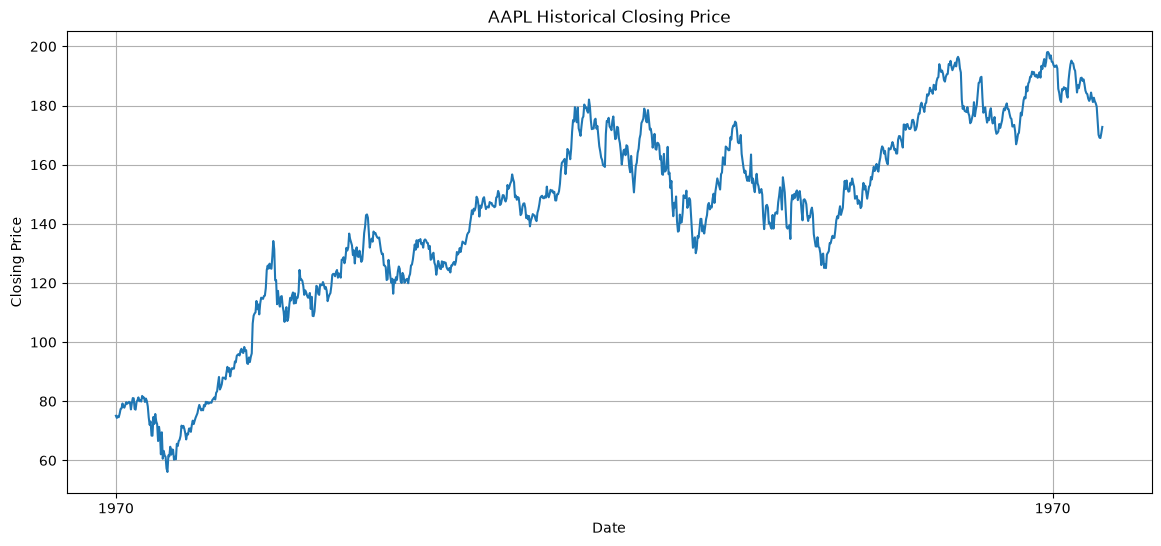

In [11]:
# Plot historical closing prices

plt.figure(figsize=(14, 6))

plt.plot(df.index, df["Close"])

plt.title("AAPL Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)
plt.show()

## Select the target variable
## Select Closing Price

The closing price is selected as the target variable for forecasting. Only the closing price is used as the input feature for this LSTM model.

In [18]:
data = df[["Close"]].copy()

print("Selected data:")
print(data.head())

print("\nShape of selected data:")
print(data.shape)

Selected data:
                                   Close
1970-01-01 00:00:00.000000000  75.087502
1970-01-01 00:00:00.000000001  74.357498
1970-01-01 00:00:00.000000002  74.949997
1970-01-01 00:00:00.000000003  74.597504
1970-01-01 00:00:00.000000004  75.797501

Shape of selected data:
(1054, 1)


## Check missing values again

In [19]:

print(data.isnull().sum())

Close    0
dtype: int64


## Normalize the data

The closing prices are normalized to a range between 0 and 1 using Min-Max scaling. Normalization helps the LSTM model train efficiently and improves numerical stability during training.

In [20]:
# Create Min-Max scaler

scaler = MinMaxScaler(feature_range=(0, 1))

# Normalize the closing prices

scaled_data = scaler.fit_transform(data[["Close"]])

print("First 5 normalized values:")
print(scaled_data[:5])

First 5 normalized values:
[[0.13375114]
 [0.1286109 ]
 [0.13278292]
 [0.13030088]
 [0.13875052]]


## Create time-series sequences

LSTM networks require sequential input data.

In this project, the previous 60 trading days are used to predict the closing price of the next trading day.

For example:
Days 1–60 → Predict Day 61
Days 2–61 → Predict Day 62
Days 3–62 → Predict Day 63

In [21]:
# Number of previous trading days used for prediction

sequence_length = 60

X = []
y = []

# Create input-output sequences

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])
    y.append(scaled_data[i, 0])

# Convert lists to NumPy arrays

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (994, 60)
y shape: (994,)


## Reshape data for LSTM

LSTM networks require input data in the following format:
Samples × Time Steps × Features

Each sample contains 60 previous trading days and one feature, which is the closing price.

In [22]:
# Reshape input data for LSTM

X = X.reshape((X.shape[0], X.shape[1], 1))

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (994, 60, 1)
Final y shape: (994,)


## Train-test split

In [23]:
# Calculate training size

train_size = int(len(X) * 0.8)

# Chronological train-test split

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 795
Testing samples: 199


## Build the LSTM model
A Long Short-Term Memory (LSTM) neural network is used because LSTM networks are designed to learn patterns and dependencies in sequential
data.

The model contains two LSTM layers, dropout layers, and dense layers.
The final output layer produces one predicted stock closing price.

In [24]:
# Create the LSTM model

model = Sequential()

# First LSTM layer
model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

# Dropout layer
model.add(Dropout(0.2))

# Second LSTM layer
model.add(
    LSTM(
        50,
        return_sequences=False
    )
)

# Dropout layer
model.add(Dropout(0.2))

# Dense hidden layer
model.add(Dense(25))

# Output layer
model.add(Dense(1))

# Display model architecture
model.summary()

C:\Users\Aksha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the model

In [25]:
# Compile the model

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

print("Model compiled successfully.")

Model compiled successfully.


## Train the model

In [26]:
# Train the model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - loss: 0.0568 - val_loss: 0.0094
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0084 - val_loss: 0.0036
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0061 - val_loss: 0.0018
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0058 - val_loss: 0.0033
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0042 - val_loss: 0.0012
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.0047 - val_loss: 0.0028
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0044 - val_loss: 0.0012
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0041 - val_loss: 0.0017
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0040 - val_loss: 0.0012
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0034 - val_loss: 9.6237e-04
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0035 - val_loss: 6.6809e-04
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - 

## Plot training and validation loss

The training and validation loss curves are plotted to analyze the
learning behavior of the LSTM model. A decreasing loss generally indicates that the model is learning
patterns from the training data.

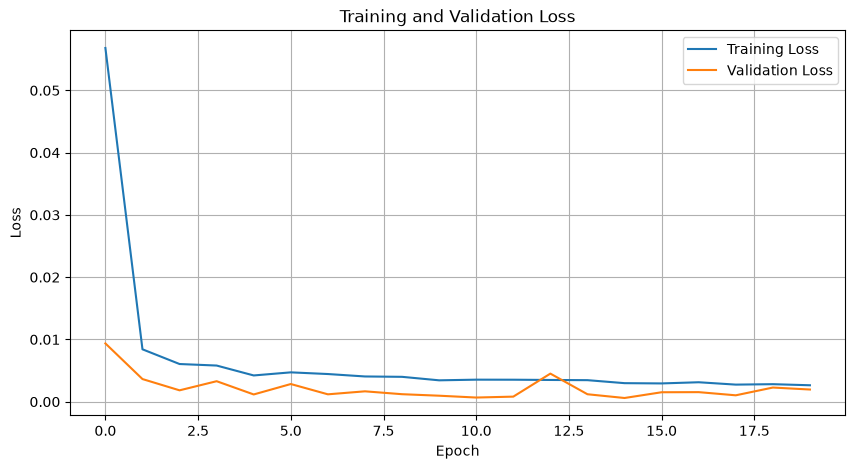

In [27]:

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

## Generate predictions
The trained LSTM model is used to predict closing prices for the
unseen testing dataset.

In [29]:

predictions = model.predict(X_test)

print("Prediction shape:", predictions.shape)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
Prediction shape: (199, 1)


## Convert predictions back to original prices

The model currently predicts normalized values between 0 and 1.
The predicted values are converted from the normalized scale back to
the original stock-price scale using the inverse transformation of
MinMaxScaler.

In [30]:
# Convert predictions back to original price scale

predictions = scaler.inverse_transform(predictions)

# Convert actual test values back to original scale

actual_prices = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

print("First 5 predicted prices:")
print(predictions[:5])

print("\nFirst 5 actual prices:")
print(actual_prices[:5])

First 5 predicted prices:
[[168.40674]
 [168.29683]
 [168.31972]
 [168.54427]
 [168.89328]]

First 5 actual prices:
[[172.99000549]
 [175.42999268]
 [177.30000305]
 [177.25      ]
 [180.08999634]]


## Calculate MAE
## Mean Absolute Error (MAE)

Mean Absolute Error measures the average absolute difference between
the actual and predicted stock prices. A lower MAE indicates better prediction performance.

In [31]:

mae = mean_absolute_error(
    actual_prices,
    predictions
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 7.159644198777088


## Calculate RMSE
## Root Mean Squared Error (RMSE)

Root Mean Squared Error measures the square root of the average
squared difference between actual and predicted stock prices. A lower RMSE indicates better forecasting performance.

In [32]:

rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predictions
    )
)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 8.19524705279324


## Actual vs Predicted Stock Prices

The actual and predicted stock prices are plotted together to
visually evaluate the performance of the LSTM forecasting model.

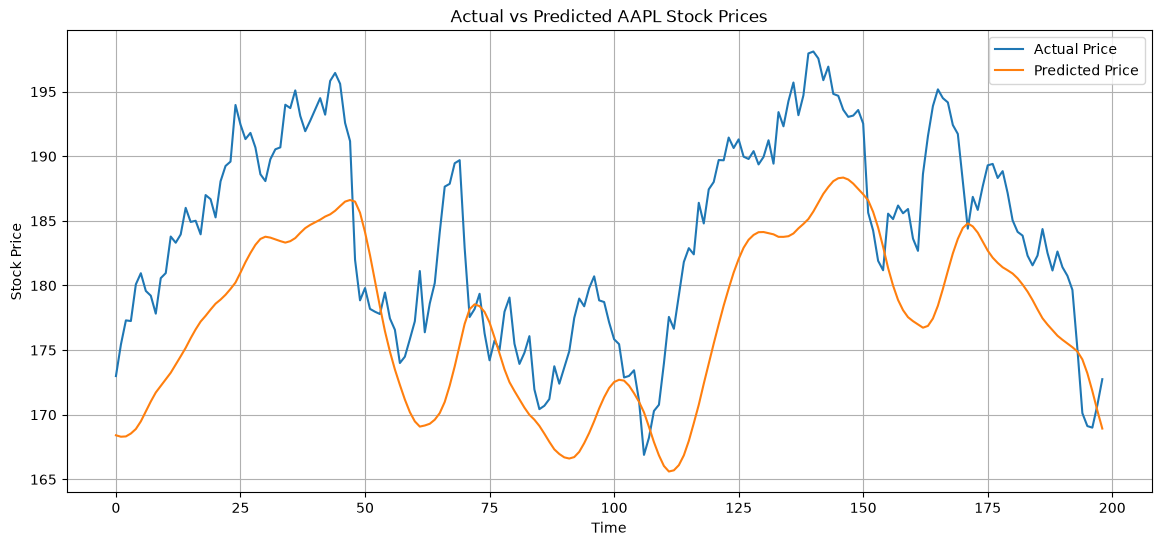

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_prices,
    label="Actual Price"
)

plt.plot(
    predictions,
    label="Predicted Price"
)

plt.title("Actual vs Predicted AAPL Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)

plt.show()

## Create comparison table

In [34]:
comparison = pd.DataFrame({
    "Actual Price": actual_prices.flatten(),
    "Predicted Price": predictions.flatten()
})

comparison.head(10)

,Actual Price,Predicted Price
0,172.990005,168.406738
1,175.429993,168.296829
2,177.300003,168.319717
3,177.250000,168.544266
4,180.089996,168.893280
5,180.949997,169.483887
6,179.580002,170.255981
7,179.210007,171.023422
8,177.820007,171.718353
9,180.570007,172.229904


## Predict the Next Closing Price

The most recent 60 trading days are given to the trained LSTM model
to estimate the next closing price.



In [35]:
# Select the latest 60 trading days

last_60_days = scaled_data[-sequence_length:]

# Reshape for LSTM input

last_60_days = last_60_days.reshape(
    1,
    sequence_length,
    1
)

# Predict the next normalized price

next_day_scaled = model.predict(last_60_days)

# Convert the prediction back to the original price scale

next_day_price = scaler.inverse_transform(
    next_day_scaled
)

print(
    "Predicted next closing price:",
    next_day_price[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted next closing price: 167.8097


## Final performance

In [36]:
print("=" * 50)
print("LSTM STOCK PRICE FORECASTING RESULTS")
print("=" * 50)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

print(
    f"Predicted Next Closing Price: "
    f"{next_day_price[0][0]:.2f}"
)

LSTM STOCK PRICE FORECASTING RESULTS
MAE  : 7.1596
RMSE : 8.1952
Predicted Next Closing Price: 167.81
